<a href="https://colab.research.google.com/github/Ganasa18/belajar-tensorflow/blob/main/train_class_prompt_labeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# =========================================================
# GOOGLE DRIVE PERSISTENT STORAGE SETUP - SAFE VERSION
# =========================================================

from google.colab import drive
import os
import shutil

# 1. COBA MOUNT DRIVE LAGI

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=True
)

assert os.path.exists("/content/drive/MyDrive"), \
    "Google Drive belum mounted"

SAVE_DIR = "/content/drive/MyDrive/router_classifier"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Persistent storage OK:", SAVE_DIR)

DRIVE_MOUNT = "/content/drive"
SAVE_DIR = "/content/router_classifier_temp"

drive_ok = False

try:
    drive.mount(
        DRIVE_MOUNT,
        force_remount=False
    )

    SAVE_DIR = (
        f"{DRIVE_MOUNT}/MyDrive/router_classifier"
    )

    os.makedirs(
        SAVE_DIR,
        exist_ok=True
    )

    drive_ok = True

    print("Google Drive mounted.")
    print("Persistent SAVE_DIR:", SAVE_DIR)

except Exception as e:

    print("WARNING: Google Drive gagal dimount.")
    print(type(e).__name__, e)

    print()
    print("Fallback sementara ke /content.")
    print("DATA BISA HILANG jika runtime restart.")

    SAVE_DIR = "/content/router_classifier_temp"

    os.makedirs(
        SAVE_DIR,
        exist_ok=True
    )


# =========================================================
# PATH CONFIG
# =========================================================

SAVE_DIR = "/content/drive/MyDrive/router_classifier"

BASE_PATH = f"{SAVE_DIR}/router_teacher_checkpoint.csv"
EXTRA_ALL_PATH = f"{SAVE_DIR}/router_teacher_extra_all.csv"
CURRENT_DATASET_PATH = f"{SAVE_DIR}/router_dataset_current.csv"
CURRENT_MODEL_PATH = f"{SAVE_DIR}/router_classifier_current.joblib"
ROUND_LOG_PATH = f"{SAVE_DIR}/router_tuning_rounds.csv"


print()
print("=" * 60)
print("STORAGE STATUS")
print("=" * 60)

print("Drive mounted :", drive_ok)
print("SAVE_DIR      :", SAVE_DIR)

print()

Mounted at /content/drive
Persistent storage OK: /content/drive/MyDrive/router_classifier
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Persistent SAVE_DIR: /content/drive/MyDrive/router_classifier

STORAGE STATUS
Drive mounted : True
SAVE_DIR      : /content/drive/MyDrive/router_classifier



In [21]:
# 1. Install library
!pip install -q datasets pandas requests tqdm scikit-learn sentence-transformers joblib

In [22]:
# 2. Download dataset Indonesia

from datasets import load_dataset

ds = load_dataset(
    "ilhamfadheel/alpaca-cleaned-indonesian",
    split="train"
)

print(ds)
print(ds[0])

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 45631
})
{'instruction': 'Sebutkan tiga senyawa organik.', 'input': '', 'output': 'Tiga senyawa organik adalah glukosa (C6H12O6), metana (CH4), dan etanol (C2H5OH).'}


In [23]:
# # Ambil 5.000 prompt dulu
# SAMPLE_SIZE = 5000

# ds_small = ds.shuffle(seed=42).select(
#     range(min(SAMPLE_SIZE, len(ds)))
# )

# def build_prompt(row):
#     instruction = row["instruction"].strip()
#     input_text = row["input"].strip()

#     if input_text:
#         return instruction + "\n" + input_text

#     return instruction

# prompts = [build_prompt(x) for x in ds_small]

# print("Jumlah prompt:", len(prompts))

# for x in prompts[:5]:
#     print("\n---")
#     print(x)

In [24]:
# 4. Buat label router SIMPLE
# Fakta sederhana, lookup, klasifikasi sederhana,
# jawaban singkat, operasi mudah.

# GENERAL
# Penjelasan umum yang tidak membutuhkan reasoning berat.

# REASONING
# Analisis, matematika, planning, comparison,
# trade-off, deduksi, multi-step problem.

# CODING_SIMPLE
# Generate snippet sederhana, regex, SQL sederhana,
# fungsi kecil, syntax.

# CODING_COMPLEX
# Debugging kompleks, architecture, multi-file,
# race condition, performance, security review.

# TRANSFORM
# Translation, summarization, rewrite,
# extract, shorten, formatting.

# CREATIVE
# Story, brainstorming kreatif, slogan,
# dialog, ide kreatif.

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]

In [25]:
# 5. Konfigurasi API teacher
import os

BASE_URL = "https://openrouter.ai/api/v1/chat/completions"
API_KEY = "ISI_API_KEY"
MODEL = "openrouter/free"

TEMPERATURE = 0
TIMEOUT = 90

In [26]:
from google.colab import userdata
API_KEY = userdata.get('OPEN_ROUTER')

In [27]:
# 6. Teacher prompt
SYSTEM_PROMPT = """
You are labeling user prompts for an AI model router.

Classify each prompt into EXACTLY ONE label:

SIMPLE
- Simple factual questions
- Easy lookup
- Basic classification
- Very short/simple task
- Does not require substantial reasoning

GENERAL
- General explanation
- Normal knowledge question
- Moderate general assistant task
- Does not clearly belong to another category

REASONING
- Mathematics
- Multi-step reasoning
- Planning
- Comparison and trade-offs
- Analysis
- Deduction
- Complex decision making

CODING_SIMPLE
- Small code snippets
- Simple functions
- Regex
- Basic SQL
- Syntax questions
- Straightforward programming tasks

CODING_COMPLEX
- Complex debugging
- Software architecture
- Multi-component systems
- Race conditions
- Security/code review
- Performance optimization
- Complex implementation

TRANSFORM
- Translation
- Summarization
- Rewrite
- Shortening
- Extraction
- Reformatting
- Changing an existing text without requiring substantial new reasoning

CREATIVE
- Story writing
- Creative brainstorming
- Dialogue
- Slogans
- Fiction
- Creative ideation

Important rules:

1. Classify based on USER INTENT, not individual keywords.
2. The prompt may be Indonesian, English, or mixed Indonesian-English.
3. Technical words do NOT automatically mean CODING.
4. Mentioning a language such as "Bahasa Inggris" does NOT automatically mean TRANSFORM.
5. "Explain" does NOT automatically mean REASONING.
6. Choose CODING_COMPLEX only if strong technical reasoning or debugging is actually required.
7. Use SIMPLE for genuinely easy tasks.
8. Return valid JSON only.

Output schema:

{
  "label": "ONE_LABEL",
  "difficulty": 1,
  "confidence": 0.95
}

difficulty must be integer 1-5.
confidence must be number 0-1.
"""

In [28]:
# 7. Fungsi call API
import requests
import time

def call_teacher(prompt):
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }

    payload = {
        "model": MODEL,
        "temperature": 0,
        "messages": [
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    }

    print("  -> POST", BASE_URL)
    print("  -> model:", MODEL)

    start = time.time()

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,

        # jangan 90 detik dulu untuk debugging
        timeout=(10, 30)
    )

    print(
        f"  <- HTTP {response.status_code}"
        f" ({time.time() - start:.2f}s)"
    )

    response.raise_for_status()

    data = response.json()

    return data["choices"][0]["message"]["content"]

In [31]:
# 8. Parser JSON yang lebih tahan error

import re

import json
import re

def parse_teacher_output(text):
    if not text:
        raise ValueError("Teacher mengembalikan response kosong")

    text = text.strip()

    # Hapus markdown fence kalau model memberi ```json
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.I)
    text = re.sub(r"\s*```$", "", text)

    # Cari object JSON
    match = re.search(r'\{[\s\S]*?\}', text)

    if not match:
        raise ValueError(
            f"Teacher tidak mengembalikan JSON. Raw: {text[:300]!r}"
        )

    try:
        data = json.loads(match.group())
    except json.JSONDecodeError as e:
        raise ValueError(
            f"JSON teacher rusak: {match.group()[:300]}"
        ) from e

    label = data.get("label")

    try:
        difficulty = int(data.get("difficulty"))
        confidence = float(data.get("confidence"))
    except (TypeError, ValueError):
        raise ValueError(
            f"difficulty/confidence invalid: {data}"
        )

    if label not in LABELS:
        raise ValueError(f"Label invalid: {label}")

    if not 1 <= difficulty <= 5:
        raise ValueError(f"Difficulty invalid: {difficulty}")

    if not 0 <= confidence <= 1:
        raise ValueError(f"Confidence invalid: {confidence}")

    return {
        "label": label,
        "difficulty": difficulty,
        "confidence": confidence,
    }

In [33]:
# 9. Tes 1 prompt dulu
import json

test_prompt = """
review architecture backend saya dan cari kemungkinan
race condition serta bottleneck performance
"""

raw = call_teacher(test_prompt)

print("RAW:")
print(raw)

parsed = parse_teacher_output(raw)

print("\nPARSED:")
print(parsed)

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (23.38s)
RAW:
{
  "label": "CODING_COMPLEX",
  "difficulty": 4,
  "confidence": 0.95
}

PARSED:
{'label': 'CODING_COMPLEX', 'difficulty': 4, 'confidence': 0.95}


In [34]:
# 11. Teacher labeling + checkpoint
import pandas as pd
import os

CHECKPOINT_PATH = "/content/router_teacher_checkpoint.csv"

if os.path.exists(CHECKPOINT_PATH):
    df_result = pd.read_csv(CHECKPOINT_PATH)

    print(
        "Resume checkpoint:",
        len(df_result),
        "prompt"
    )

else:
    df_result = pd.DataFrame(
        columns=[
            "prompt",
            "label",
            "difficulty",
            "confidence",
            "status"
        ]
    )

    print("Checkpoint belum ada, mulai dari 0")

print(df_result.head())
print("Rows:", len(df_result))

Checkpoint belum ada, mulai dari 0
Empty DataFrame
Columns: [prompt, label, difficulty, confidence, status]
Index: []
Rows: 0


In [35]:
# #12. Loop labeling DEPRECTATED FLOW

# from tqdm.auto import tqdm
# import time

# START_INDEX = len(df_result)

# SAVE_EVERY = 20
# MAX_RETRIES = 3

# results = df_result.to_dict("records")

# print("Mulai dari index:", START_INDEX)
# print("Total prompt:", len(prompts))

# for i in tqdm(
#     range(START_INDEX, len(prompts)),
#     initial=START_INDEX,
#     total=len(prompts)
# ):

#     prompt = prompts[i]
#     success = False

#     for attempt in range(MAX_RETRIES):
#         try:
#             raw = call_teacher(prompt)
#             parsed = parse_teacher_output(raw)

#             results.append({
#                 "prompt": prompt,
#                 "label": parsed["label"],
#                 "difficulty": parsed["difficulty"],
#                 "confidence": parsed["confidence"],
#                 "status": "ok"
#             })

#             success = True
#             break

#         except Exception as e:
#             print(
#                 f"\nError index {i}, "
#                 f"attempt {attempt + 1}/{MAX_RETRIES}: "
#                 f"{type(e).__name__}: {e}"
#             )

#             try:
#                 print("RAW RESPONSE:", raw[:500])
#             except:
#                 pass

#         time.sleep(2 * (attempt + 1))

#     if not success:
#         results.append({
#             "prompt": prompt,
#             "label": None,
#             "difficulty": None,
#             "confidence": None,
#             "status": "error"
#         })

#     if (
#         (i + 1) % SAVE_EVERY == 0
#         or i == len(prompts) - 1
#     ):
#         pd.DataFrame(results).to_csv(
#             CHECKPOINT_PATH,
#             index=False
#         )

#         print(
#             f"\nCheckpoint saved: "
#             f"{len(results)}/{len(prompts)}"
#         )

# print("Labeling selesai")

In [38]:
SAVE_DIR = "/content/drive/MyDrive/router_classifier"

CHECKPOINT_PATH = f"{SAVE_DIR}/router_teacher_checkpoint.csv"
EXTRA_ALL_PATH = f"{SAVE_DIR}/router_teacher_extra_all.csv"
CURRENT_DATASET_PATH = f"{SAVE_DIR}/router_dataset_current.csv"
CURRENT_MODEL_PATH = f"{SAVE_DIR}/router_classifier_current.joblib"
ROUND_LOG_PATH = f"{SAVE_DIR}/router_tuning_rounds.csv"

import os
import pandas as pd

print("Checkpoint path:", CHECKPOINT_PATH)
print("Exists:", os.path.exists(CHECKPOINT_PATH))

if os.path.exists(CHECKPOINT_PATH):
    df = pd.read_csv(CHECKPOINT_PATH)
    print("Total tersimpan:", len(df))
else:
    print("Checkpoint belum ditemukan.")

Checkpoint path: /content/drive/MyDrive/router_classifier/router_teacher_checkpoint.csv
Exists: True
Total tersimpan: 100


In [39]:
# 13. Load hasil final LOAD CHECKPOINT / FINAL RESULT

import pandas as pd

df = pd.read_csv(CHECKPOINT_PATH)

print("Total tersimpan:", len(df))
print()

print("Status:")
print(df["status"].value_counts(dropna=False))
print()

print("Label:")
print(df["label"].value_counts(dropna=False))
print()

print("Shape:", df.shape)

Total tersimpan: 100

Status:
status
ok    100
Name: count, dtype: int64

Label:
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

Shape: (100, 5)


In [40]:
# 14. Hapus request yang gagal

df_clean = df[
    df["status"] == "ok"
].copy()

df_clean = df[
    df["status"] == "ok"
].copy()

df_clean.to_csv(
    "/content/router_seed_indonesia.csv",
    index=False
)

print("Seed Indonesia:", len(df_clean))

Seed Indonesia: 100


In [41]:
# 15. Lihat distribusi label

print(
    df_clean["label"].value_counts()
)

print()

print(
    df_clean["label"]
    .value_counts(normalize=True)
    .round(3)
)

label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

label
SIMPLE           0.35
CREATIVE         0.23
GENERAL          0.22
TRANSFORM        0.13
REASONING        0.05
CODING_SIMPLE    0.02
Name: proportion, dtype: float64


In [42]:
# 16. Filter confidence rendah

MIN_CONFIDENCE = 0.80

df_high = df_clean[
    df_clean["confidence"] >= MIN_CONFIDENCE
].copy()

print(
    "High confidence:",
    len(df_high)
)

print()

print(
    df_high["label"].value_counts()
)

High confidence: 100

label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64


In [43]:
# 17. Lihat prompt yang teacher tidak yakin

uncertain = df_clean.sort_values(
    "confidence"
)

print(
    uncertain[
        [
            "prompt",
            "label",
            "difficulty",
            "confidence"
        ]
    ]
    .head(30)
    .to_string(index=False)
)

                                                                                                                                                                                                                                                                                                                                     prompt         label  difficulty  confidence
                                                                                                                                                                                                                                                                                    Buat iklan lowongan pekerjaan untuk copy editor online.      CREATIVE           2        0.85
                                                                                                                                                                                                                                                             Hasilka

In [44]:
# 18. Lihat contoh setiap kategori

for label in LABELS:

    print("\n")
    print("=" * 70)
    print(label)
    print("=" * 70)

    samples = (
        df_high[
            df_high["label"] == label
        ]
        .sample(
            min(
                10,
                len(
                    df_high[
                        df_high["label"]
                        == label
                    ]
                )
            ),
            random_state=42
        )
    )

    for _, row in samples.iterrows():

        print(
            f"\n[{row['confidence']:.2f}]",
            row["prompt"][:300]
        )



SIMPLE

[0.95] Temukan kelipatan persekutuan terkecil dari 15 dan 20

[0.95] Tulis persamaan untuk menghitung total biaya suatu produk.
Harga produk = $24
Kuantitas = 3
Biaya pengiriman = $8

[0.95] Jelaskan arti frasa "carpe diem".

[0.95] Kelompokkan kata-kata menurut bagian pidatonya.
Kuat, panjang, apel

[0.95] Bacalah pengamatan berikut dan beri label sebagai kekuatan atau kelemahan.
Situs web ini ramah pengguna dan mudah dinavigasi.

[0.96] Sebutkan ciri-ciri mobil tahun 1950an.

[0.95] Pilihlah kalimat yang paling mencerminkan pendapat yang diberikan
Saya lebih suka melakukan aktivitas lain selain berbelanja di akhir pekan

[0.95] Cocokkan setiap item dengan salah satu dari empat musim.
Salju, Berkemah, Pantai, Anggur

[0.98] Kategorikan kata berikut ke dalam kelas kata yang sesuai.
Cantik

[0.95] Jika diberi resep, sarankan hidangan yang sesuai untuk menyajikannya.
Resep: Lasagna Keju


GENERAL

[0.93] Jelaskan faktor-faktor yang berkontribusi terhadap krisis ekonomi global s

In [45]:
# 19. Export teacher dataset
FINAL_DATASET = (
    "/content/router_teacher_labeled.csv"
)

df_high.to_csv(
    FINAL_DATASET,
    index=False
)

print(FINAL_DATASET)

/content/router_teacher_labeled.csv


In [46]:
# 20. Training classifier baru

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2"
)

X = embedding_model.encode(
    df_high["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

y = df_high["label"].values

print(X.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

(100, 384)


In [47]:
# 21. Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(
    len(X_train),
    len(X_test)
)

80 20


In [48]:
# 22. Train Logistic Regression
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(
    max_iter=2000,
    random_state=42
)

classifier.fit(
    X_train,
    y_train
)

print("Done")

Done


In [49]:
# 23. Evaluate

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

pred = classifier.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print()

print(
    classification_report(
        y_test,
        pred,
        digits=3
    )
)

Accuracy: 0.65

              precision    recall  f1-score   support

    CREATIVE      1.000     0.800     0.889         5
     GENERAL      0.667     0.500     0.571         4
   REASONING      0.000     0.000     0.000         1
      SIMPLE      0.538     1.000     0.700         7
   TRANSFORM      0.000     0.000     0.000         3

    accuracy                          0.650        20
   macro avg      0.441     0.460     0.432        20
weighted avg      0.572     0.650     0.582        20



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
# 24. Confusion matrix
from sklearn.metrics import confusion_matrix

labels_sorted = list(
    classifier.classes_
)

cm = confusion_matrix(
    y_test,
    pred,
    labels=labels_sorted
)

cm_df = pd.DataFrame(
    cm,
    index=labels_sorted,
    columns=labels_sorted
)

print(cm_df)

               CODING_SIMPLE  CREATIVE  GENERAL  REASONING  SIMPLE  TRANSFORM
CODING_SIMPLE              0         0        0          0       0          0
CREATIVE                   0         4        0          0       1          0
GENERAL                    0         0        2          0       2          0
REASONING                  0         0        1          0       0          0
SIMPLE                     0         0        0          0       7          0
TRANSFORM                  0         0        0          0       3          0


In [51]:
# 25. Test prompt Indonesia nyata
test_prompts = [
    "berapa 15 persen dari 500",

    "jelaskan fungsi docker compose",

    "bandingkan REST dan GraphQL "
    "untuk backend aplikasi besar",

    "buat regex untuk validasi email",

    "debug kenapa service systemd saya "
    "restart terus dan cek kemungkinan "
    "race condition",

    "ringkas tulisan ini menjadi 5 poin",

    "terjemahkan kalimat ini ke bahasa jepang",

    "buat cerita pendek tentang robot kecil",

    "kenapa request ke API direct cepat "
    "tapi lewat router jadi lambat",

    "review architecture backend saya, "
    "analisis bottleneck, retry strategy, "
    "dan desain ulang flow request"
]

emb = embedding_model.encode(
    test_prompts,
    normalize_embeddings=True
)

prediction = classifier.predict(
    emb
)

probability = classifier.predict_proba(
    emb
)

for prompt, label, probs in zip(
    test_prompts,
    prediction,
    probability
):

    confidence = probs.max()

    print("\nPROMPT:")
    print(prompt)

    print(
        "ROUTE:",
        label
    )

    print(
        "CONFIDENCE:",
        round(
            float(confidence),
            3
        )
    )


PROMPT:
berapa 15 persen dari 500
ROUTE: SIMPLE
CONFIDENCE: 0.448

PROMPT:
jelaskan fungsi docker compose
ROUTE: SIMPLE
CONFIDENCE: 0.433

PROMPT:
bandingkan REST dan GraphQL untuk backend aplikasi besar
ROUTE: SIMPLE
CONFIDENCE: 0.384

PROMPT:
buat regex untuk validasi email
ROUTE: SIMPLE
CONFIDENCE: 0.34

PROMPT:
debug kenapa service systemd saya restart terus dan cek kemungkinan race condition
ROUTE: SIMPLE
CONFIDENCE: 0.383

PROMPT:
ringkas tulisan ini menjadi 5 poin
ROUTE: SIMPLE
CONFIDENCE: 0.52

PROMPT:
terjemahkan kalimat ini ke bahasa jepang
ROUTE: SIMPLE
CONFIDENCE: 0.34

PROMPT:
buat cerita pendek tentang robot kecil
ROUTE: SIMPLE
CONFIDENCE: 0.336

PROMPT:
kenapa request ke API direct cepat tapi lewat router jadi lambat
ROUTE: SIMPLE
CONFIDENCE: 0.375

PROMPT:
review architecture backend saya, analisis bottleneck, retry strategy, dan desain ulang flow request
ROUTE: GENERAL
CONFIDENCE: 0.399


In [52]:
# # 26. Simpan classifier
import joblib

MODEL_PATH = (
    "/content/router_classifier_v2.joblib"
)

joblib.dump(
    classifier,
    MODEL_PATH
)

print(MODEL_PATH)

print(df_high["label"].value_counts())

/content/router_classifier_v2.joblib
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64


In [53]:
# 27. TARGET BALANCE

TARGET_PER_LABEL = 60

current_counts = df_high["label"].value_counts()

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]

needed = {}

for label in LABELS:
    current = int(current_counts.get(label, 0))
    needed[label] = max(0, TARGET_PER_LABEL - current)

print("Current:")
print(current_counts)

print("\nNeed additional:")
for label, count in needed.items():
    print(label, ":", count)

Current:
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

Need additional:
SIMPLE : 25
GENERAL : 38
REASONING : 55
CODING_SIMPLE : 58
CODING_COMPLEX : 60
TRANSFORM : 47
CREATIVE : 37


In [54]:
# 28. EXTRA PROMPTS

extra_prompts = [
    # CODING_SIMPLE
    "buat regex untuk validasi email",
    "buat function python untuk parsing json",
    "buat query SQL untuk mengambil 10 user terbaru",
    "buat fungsi javascript untuk debounce",
    "buat contoh request fetch API sederhana",

    # CODING_COMPLEX
    "debug kenapa service systemd restart terus setelah dependency timeout",
    "review architecture microservice dan cari race condition",
    "analisis bottleneck concurrency pada worker queue",
    "review strategi retry dan circuit breaker untuk API yang sering gagal",
    "analisis security dan performance flow authentication"
]

print("Extra prompts:", len(extra_prompts))

Extra prompts: 10


In [55]:
# 29. TEACHER LABEL EXTRA

extra_results = []

for i, prompt in enumerate(extra_prompts, start=1):

    print(f"\n[{i}/{len(extra_prompts)}]")

    try:
        raw = call_teacher(prompt)
        parsed = parse_teacher_output(raw)

        extra_results.append({
            "prompt": prompt,
            "label": parsed["label"],
            "difficulty": parsed["difficulty"],
            "confidence": parsed["confidence"],
            "status": "ok"
        })

        print(parsed)

    except Exception as e:
        print("ERROR:", e)

        extra_results.append({
            "prompt": prompt,
            "label": None,
            "difficulty": None,
            "confidence": None,
            "status": "error"
        })


[1/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.31s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[2/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (7.79s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[3/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (5.97s)
{'label': 'CODING_SIMPLE', 'difficulty': 1, 'confidence': 0.95}

[4/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.15s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[5/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.78s)
{'label': 'CODING_SIMPLE', 'difficulty': 1, 'confidence': 0.95}

[6/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.6

In [56]:
# 30. SAVE EXTRA DATA

df_extra = pd.DataFrame(extra_results)

EXTRA_PATH = "/content/router_teacher_extra.csv"

df_extra.to_csv(
    EXTRA_PATH,
    index=False
)

print("Saved:", EXTRA_PATH)
print()
print(df_extra["label"].value_counts(dropna=False))

Saved: /content/router_teacher_extra.csv

label
CODING_SIMPLE     5
REASONING         3
CODING_COMPLEX    1
None              1
Name: count, dtype: int64


In [57]:
# 31. MERGE OLD + EXTRA

df_old = df_high.copy()

df_new = pd.read_csv(
    "/content/router_teacher_extra.csv"
)

df_new = df_new[
    (df_new["status"] == "ok") &
    (df_new["confidence"] >= 0.80)
].copy()

df_balanced = pd.concat(
    [df_old, df_new],
    ignore_index=True
)

df_balanced = df_balanced.drop_duplicates(
    subset=["prompt"]
)

print("Total:", len(df_balanced))
print()
print(df_balanced["label"].value_counts())

Total: 109

label
SIMPLE            35
CREATIVE          23
GENERAL           22
TRANSFORM         13
REASONING          8
CODING_SIMPLE      7
CODING_COMPLEX     1
Name: count, dtype: int64


In [58]:
# 32. RETRAIN V3 - SAFE VERSION


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# cek distribusi
counts = df_balanced["label"].value_counts()

print("Distribusi sebelum filter:")
print(counts)
print()

# hanya kelas dengan minimal 2 contoh
valid_labels = counts[counts >= 2].index

df_v3 = df_balanced[
    df_balanced["label"].isin(valid_labels)
].copy()

print("Distribusi setelah filter:")
print(df_v3["label"].value_counts())
print()

# embedding ulang
X_v3 = embedding_model.encode(
    df_v3["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

y_v3 = df_v3["label"].values

# split
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3,
    y_v3,
    test_size=0.2,
    random_state=42,
    stratify=y_v3
)

# train
classifier_v3 = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

classifier_v3.fit(
    X_train_v3,
    y_train_v3
)

# evaluate
pred_v3 = classifier_v3.predict(X_test_v3)

print(
    classification_report(
        y_test_v3,
        pred_v3,
        digits=3,
        zero_division=0
    )
)

Distribusi sebelum filter:
label
SIMPLE            35
CREATIVE          23
GENERAL           22
TRANSFORM         13
REASONING          8
CODING_SIMPLE      7
CODING_COMPLEX     1
Name: count, dtype: int64

Distribusi setelah filter:
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         8
CODING_SIMPLE     7
Name: count, dtype: int64



Batches:   0%|          | 0/2 [00:00<?, ?it/s]

               precision    recall  f1-score   support

CODING_SIMPLE      1.000     1.000     1.000         1
     CREATIVE      0.571     0.800     0.667         5
      GENERAL      0.500     0.500     0.500         4
    REASONING      0.333     0.500     0.400         2
       SIMPLE      0.333     0.286     0.308         7
    TRANSFORM      1.000     0.333     0.500         3

     accuracy                          0.500        22
    macro avg      0.623     0.570     0.562        22
 weighted avg      0.539     0.500     0.490        22



In [59]:
print(df_balanced["label"].value_counts())

label
SIMPLE            35
CREATIVE          23
GENERAL           22
TRANSFORM         13
REASONING          8
CODING_SIMPLE      7
CODING_COMPLEX     1
Name: count, dtype: int64


In [ ]:
# =========================================================
# AUTO TUNING SYSTEM - FULL FIXED VERSION
# =========================================================

import os
import re
import json
import time
import joblib
import pandas as pd

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score
)


# =========================================================
# 1. CONFIG
# =========================================================

MIN_CONFIDENCE = 0.80

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]


# Target TIDAK lagi satu angka.
# Bisa diubah masing-masing sesuai performa classifier.

TARGET_PER_LABEL = {
    "SIMPLE": 60,
    "GENERAL": 70,
    "REASONING": 75,
    "CODING_SIMPLE": 50,
    "CODING_COMPLEX": 60,
    "TRANSFORM": 50,
    "CREATIVE": 40,
}


CATEGORY_DESCRIPTIONS = {

    "SIMPLE":
        "Simple factual questions, easy lookup, simple calculation, "
        "basic classification, definitions, and short easy tasks. "
        "The task should require very little reasoning.",

    "GENERAL":
        "Normal general assistant questions and explanations without "
        "substantial multi-step reasoning. These may ask how something "
        "works or request a normal explanation, but should not require "
        "complex comparison, deduction, planning, or software implementation.",

    "REASONING":
        "Non-coding analytical tasks requiring comparison, planning, "
        "trade-offs, deduction, mathematics, decision making, or multi-step "
        "reasoning. Generic technology comparisons belong here when they "
        "do not require debugging, implementing, reviewing, optimizing, "
        "or architecting an actual software system.",

    "CODING_SIMPLE":
        "Small programming tasks such as regex, basic SQL, short functions, "
        "syntax questions, small scripts, simple code modification, "
        "or straightforward implementation that does not require "
        "significant software architecture reasoning.",

    "CODING_COMPLEX":
        "Software engineering tasks requiring substantial technical reasoning "
        "involving actual software systems, code, APIs, backend/frontend "
        "architecture, debugging, concurrency, race conditions, security "
        "review, performance optimization, distributed systems, databases, "
        "system design, or multi-component implementation. "
        "A generic technology comparison without implementation or "
        "software engineering analysis is REASONING.",

    "TRANSFORM":
        "Tasks whose primary purpose is transforming existing user-provided "
        "content, including translation, summarization, rewriting, extraction, "
        "shortening, formatting, restructuring, or converting text/data "
        "into another representation.",

    "CREATIVE":
        "Creative writing and ideation such as stories, dialogue, fictional "
        "content, slogans, names, concepts, imaginative brainstorming, "
        "characters, scenarios, or creative variations."
}


# =========================================================
# 2. FILE PATHS
# =========================================================

SAVE_DIR = "/content/drive/MyDrive/router_classifier"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

BASE_PATH = (
    f"{SAVE_DIR}/router_teacher_checkpoint.csv"
)

EXTRA_ALL_PATH = (
    f"{SAVE_DIR}/router_teacher_extra_all.csv"
)

CURRENT_DATASET_PATH = (
    f"{SAVE_DIR}/router_dataset_current.csv"
)

CURRENT_MODEL_PATH = (
    f"{SAVE_DIR}/router_classifier_current.joblib"
)

ROUND_LOG_PATH = (
    f"{SAVE_DIR}/router_tuning_rounds.csv"
)


print("SAVE_DIR:", SAVE_DIR)
print("BASE_PATH:", BASE_PATH)


# =========================================================
# 3. SANITY CHECK
# =========================================================

missing_dependencies = []

if "call_teacher" not in globals():
    missing_dependencies.append(
        "call_teacher"
    )

if "parse_teacher_output" not in globals():
    missing_dependencies.append(
        "parse_teacher_output"
    )

if "embedding_model" not in globals():
    missing_dependencies.append(
        "embedding_model"
    )

if missing_dependencies:

    raise RuntimeError(
        "Jalankan setup sebelumnya dulu. "
        "Dependency belum tersedia: "
        + ", ".join(
            missing_dependencies
        )
    )


for label in LABELS:

    if label not in TARGET_PER_LABEL:

        raise ValueError(
            f"TARGET_PER_LABEL belum memiliki: {label}"
        )

    if label not in CATEGORY_DESCRIPTIONS:

        raise ValueError(
            f"CATEGORY_DESCRIPTIONS belum memiliki: {label}"
        )


# =========================================================
# 4. LOAD CURRENT DATASET
# =========================================================

def load_current_dataset():

    if not os.path.exists(
        BASE_PATH
    ):

        raise FileNotFoundError(
            "Base dataset tidak ditemukan:\n"
            f"{BASE_PATH}"
        )

    df_base = pd.read_csv(
        BASE_PATH
    )

    required_columns = {
        "prompt",
        "label",
        "confidence",
        "status"
    }

    missing_columns = (
        required_columns
        - set(df_base.columns)
    )

    if missing_columns:

        raise ValueError(
            "Kolom base dataset kurang: "
            + ", ".join(
                sorted(
                    missing_columns
                )
            )
        )

    # -----------------------------------------------------
    # CLEAN BASE
    # -----------------------------------------------------

    df_base["confidence"] = (
        pd.to_numeric(
            df_base["confidence"],
            errors="coerce"
        )
    )

    df_base = df_base[
        (df_base["status"] == "ok")
        &
        (
            df_base["confidence"]
            >= MIN_CONFIDENCE
        )
        &
        (
            df_base["label"]
            .isin(LABELS)
        )
    ].copy()

    # -----------------------------------------------------
    # LOAD EXTRA
    # -----------------------------------------------------

    if os.path.exists(
        EXTRA_ALL_PATH
    ):

        df_extra = pd.read_csv(
            EXTRA_ALL_PATH
        )

        if len(df_extra) > 0:

            df_extra["confidence"] = (
                pd.to_numeric(
                    df_extra["confidence"],
                    errors="coerce"
                )
            )

            df_extra = df_extra[
                (df_extra["status"] == "ok")
                &
                (
                    df_extra["confidence"]
                    >= MIN_CONFIDENCE
                )
                &
                (
                    df_extra["label"]
                    .isin(LABELS)
                )
            ].copy()

    else:

        df_extra = pd.DataFrame(
            columns=df_base.columns
        )

    # -----------------------------------------------------
    # MERGE
    # -----------------------------------------------------

    df_all = pd.concat(
        [
            df_base,
            df_extra
        ],
        ignore_index=True
    )

    df_all["prompt"] = (
        df_all["prompt"]
        .astype(str)
        .str.strip()
    )

    df_all = df_all[
        df_all["prompt"] != ""
    ]

    df_all = (
        df_all
        .drop_duplicates(
            subset=["prompt"],
            keep="first"
        )
        .reset_index(
            drop=True
        )
    )

    return df_all


# =========================================================
# 5. CALCULATE MISSING
# =========================================================

def calculate_missing(
    df
):

    counts = (
        df["label"]
        .value_counts()
    )

    result = {}

    for label in LABELS:

        current = int(
            counts.get(
                label,
                0
            )
        )

        target = int(
            TARGET_PER_LABEL[
                label
            ]
        )

        need = max(
            0,
            target - current
        )

        result[label] = {
            "current": current,
            "target": target,
            "need": need
        }

    return result


# =========================================================
# 6. GENERATE TARGETED PROMPTS
# =========================================================

def generate_prompts_for_label(
    label,
    count
):

    if count <= 0:

        return []

    if label not in CATEGORY_DESCRIPTIONS:

        raise ValueError(
            f"Description tidak ditemukan: {label}"
        )

    definition = (
        CATEGORY_DESCRIPTIONS[
            label
        ]
    )

    request = f"""
Generate exactly {count} diverse realistic USER prompts.

TARGET CATEGORY:
{label}

CATEGORY DEFINITION:
{definition}

The dataset is being used to train a semantic routing classifier.

Very important:
Generate a mixture of obvious examples and HARD BOUNDARY examples.

Important classification boundaries include:

SIMPLE vs GENERAL:
- SIMPLE requires very little reasoning.
- GENERAL asks for normal explanations but not substantial analysis.

SIMPLE vs CODING_SIMPLE:
- A simple factual question about programming is not automatically CODING_SIMPLE.
- CODING_SIMPLE should actually ask for code, implementation, regex, SQL,
  syntax correction, or a small programming operation.

GENERAL vs REASONING:
- GENERAL is explanatory.
- REASONING requires comparison, trade-offs, deduction, planning,
  analysis, or multi-step thinking.

REASONING vs CODING_COMPLEX:
- Generic technology comparison is REASONING.
- Debugging, architecture review, concurrency analysis,
  performance investigation, security review, or implementation
  of actual software systems is CODING_COMPLEX.

TRANSFORM:
- The primary action must be transforming existing content,
  such as translation, summarization, rewriting, extraction,
  formatting, or conversion.

Every generated prompt MUST genuinely belong to:
{label}

Language distribution:
- approximately 60% Indonesian
- approximately 25% English
- approximately 15% mixed Indonesian-English

Requirements:
- natural user requests
- realistic prompts
- varied topics
- varied sentence length
- include easy and difficult examples
- include some ambiguous-looking boundary cases
- but the correct category must still be {label}
- do not answer the prompts
- no duplicates
- do not write explanations
- do not explicitly mention category names
- return ONLY one valid JSON array of strings

Example output format:

[
  "prompt pertama",
  "prompt kedua"
]
"""

    raw = call_teacher(
        request
    )

    if not raw:

        raise ValueError(
            "Teacher menghasilkan response kosong."
        )

    # Remove markdown fence if present

    cleaned_raw = (
        str(raw)
        .strip()
    )

    cleaned_raw = re.sub(
        r"^```(?:json)?\s*",
        "",
        cleaned_raw,
        flags=re.IGNORECASE
    )

    cleaned_raw = re.sub(
        r"\s*```$",
        "",
        cleaned_raw
    )

    match = re.search(
        r'\[[\s\S]*\]',
        cleaned_raw
    )

    if not match:

        raise ValueError(
            "JSON array tidak ditemukan:\n"
            + cleaned_raw[:500]
        )

    try:

        data = json.loads(
            match.group()
        )

    except json.JSONDecodeError as e:

        raise ValueError(
            "JSON prompt generator invalid:\n"
            + match.group()[:500]
        ) from e

    if not isinstance(
        data,
        list
    ):

        raise ValueError(
            "Teacher tidak menghasilkan list."
        )

    clean = []

    seen = set()

    for item in data:

        if not isinstance(
            item,
            str
        ):
            continue

        item = item.strip()

        if not item:
            continue

        normalized = (
            item.casefold()
        )

        if normalized in seen:
            continue

        seen.add(
            normalized
        )

        clean.append(
            item
        )

    return clean


# =========================================================
# 7. TEACHER VALIDATION
# =========================================================

def validate_prompts(
    prompts_to_validate
):

    results = []

    for prompt in tqdm(
        prompts_to_validate,
        desc="Teacher validation"
    ):

        success = False

        last_error = None

        for attempt in range(
            3
        ):

            try:

                raw = call_teacher(
                    prompt
                )

                parsed = (
                    parse_teacher_output(
                        raw
                    )
                )

                results.append({
                    "prompt":
                        prompt,

                    "label":
                        parsed["label"],

                    "difficulty":
                        parsed["difficulty"],

                    "confidence":
                        parsed["confidence"],

                    "status":
                        "ok"
                })

                success = True

                break

            except Exception as e:

                last_error = e

                print(
                    "\nTeacher validation error:",
                    type(e).__name__,
                    str(e)[:300]
                )

                if attempt < 2:

                    time.sleep(
                        2 * (
                            attempt + 1
                        )
                    )

        if not success:

            results.append({
                "prompt":
                    prompt,

                "label":
                    None,

                "difficulty":
                    None,

                "confidence":
                    None,

                "status":
                    "error"
            })

            print(
                "Validation failed permanently:",
                prompt[:100],
                "|",
                last_error
            )

    return results


# =========================================================
# 8. APPEND EXTRA DATA
# =========================================================

def append_extra_results(
    new_results
):

    if not new_results:

        if os.path.exists(
            EXTRA_ALL_PATH
        ):

            return pd.read_csv(
                EXTRA_ALL_PATH
            )

        return pd.DataFrame()

    df_new = pd.DataFrame(
        new_results
    )

    if os.path.exists(
        EXTRA_ALL_PATH
    ):

        df_old = pd.read_csv(
            EXTRA_ALL_PATH
        )

        df_extra = pd.concat(
            [
                df_old,
                df_new
            ],
            ignore_index=True
        )

    else:

        df_extra = df_new

    df_extra["prompt"] = (
        df_extra["prompt"]
        .astype(str)
        .str.strip()
    )

    df_extra = (
        df_extra
        .drop_duplicates(
            subset=["prompt"],
            keep="first"
        )
        .reset_index(
            drop=True
        )
    )

    df_extra.to_csv(
        EXTRA_ALL_PATH,
        index=False
    )

    return df_extra


# =========================================================
# 9. TRAIN ROUTER
# =========================================================

def train_router(
    df
):

    if len(df) == 0:

        print(
            "\nDataset kosong."
        )

        return None, None

    print(
        "\nGenerating embeddings..."
    )

    X = embedding_model.encode(
        df["prompt"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )

    y = (
        df["label"]
        .values
    )

    counts = (
        pd.Series(y)
        .value_counts()
    )

    print(
        "\nTraining distribution:"
    )

    print(
        counts
    )

    if counts.min() < 2:

        print(
            "\nBelum bisa split stratified."
        )

        return None, None

    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y,
            test_size=0.20,
            random_state=42,
            stratify=y
        )
    )

    classifier = (
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        )
    )

    classifier.fit(
        X_train,
        y_train
    )

    prediction = (
        classifier.predict(
            X_test
        )
    )

    accuracy = (
        accuracy_score(
            y_test,
            prediction
        )
    )

    macro_f1 = (
        f1_score(
            y_test,
            prediction,
            average="macro",
            zero_division=0
        )
    )

    print(
        "\n"
        + "=" * 65
    )

    print(
        "VALIDATION RESULT"
    )

    print(
        "=" * 65
    )

    print(
        "Accuracy:",
        round(
            accuracy,
            4
        )
    )

    print(
        "Macro F1:",
        round(
            macro_f1,
            4
        )
    )

    print(
        "Test samples:",
        len(
            y_test
        )
    )

    print()

    print(
        classification_report(
            y_test,
            prediction,
            digits=3,
            zero_division=0
        )
    )

    metrics = {
        "accuracy":
            float(
                accuracy
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "test_samples":
            int(
                len(
                    y_test
                )
            )
    }

    return (
        classifier,
        metrics
    )


# =========================================================
# 10. REAL TEST PROMPTS
# =========================================================

REAL_TEST_PROMPTS = [

    # SIMPLE
    "berapa 15 persen dari 500",

    "apa itu HTTP",

    # GENERAL
    "jelaskan fungsi docker compose",

    "jelaskan cara kerja DNS secara sederhana",

    # REASONING
    "bandingkan REST dan GraphQL untuk backend aplikasi besar",

    "lebih baik monolith atau microservice untuk startup kecil "
    "dengan tim developer terbatas",

    # CODING_SIMPLE
    "buat regex untuk validasi email",

    "buat function python untuk parsing json",

    # CODING_COMPLEX
    "debug kenapa service systemd restart terus dan cari "
    "kemungkinan race condition",

    "review architecture backend saya, analisis bottleneck, "
    "retry strategy, dan desain ulang flow request",

    "kenapa request API direct cepat tapi lewat router jadi lambat "
    "dan bagaimana cara mencari bottlenecknya",

    # TRANSFORM
    "ringkas tulisan ini menjadi lima poin",

    "terjemahkan kalimat ini ke bahasa Jepang",

    # CREATIVE
    "buat cerita pendek tentang robot kecil",

    "berikan ide nama untuk robot assistant cyberdeck"
]


def test_real_prompts(
    classifier
):

    if classifier is None:

        return

    print(
        "\n"
        + "=" * 65
    )

    print(
        "REAL PROMPT TEST"
    )

    print(
        "=" * 65
    )

    embeddings = (
        embedding_model.encode(
            REAL_TEST_PROMPTS,
            normalize_embeddings=True
        )
    )

    predictions = (
        classifier.predict(
            embeddings
        )
    )

    probabilities = (
        classifier.predict_proba(
            embeddings
        )
    )

    for (
        prompt,
        label,
        probs
    ) in zip(
        REAL_TEST_PROMPTS,
        predictions,
        probabilities
    ):

        confidence = float(
            probs.max()
        )

        print(
            "\nPROMPT:",
            prompt
        )

        print(
            "ROUTE:",
            label
        )

        print(
            "CONFIDENCE:",
            round(
                confidence,
                3
            )
        )


# =========================================================
# 11. SAVE ROUND LOG
# =========================================================

def save_round_log(
    df,
    metrics
):

    row = {
        "timestamp":
            pd.Timestamp.now(),

        "samples":
            len(df),

        "accuracy":
            (
                metrics["accuracy"]
                if metrics
                else None
            ),

        "macro_f1":
            (
                metrics["macro_f1"]
                if metrics
                else None
            ),

        "test_samples":
            (
                metrics["test_samples"]
                if metrics
                else None
            )
    }

    counts = (
        df["label"]
        .value_counts()
    )

    # Simpan count + target tiap label.
    # Tidak ada lagi target_per_label berupa dict di satu cell CSV.

    for label in LABELS:

        row[
            f"count_{label}"
        ] = int(
            counts.get(
                label,
                0
            )
        )

        row[
            f"target_{label}"
        ] = int(
            TARGET_PER_LABEL[
                label
            ]
        )

    df_log_new = pd.DataFrame(
        [row]
    )

    if os.path.exists(
        ROUND_LOG_PATH
    ):

        df_log_old = pd.read_csv(
            ROUND_LOG_PATH
        )

        df_log = pd.concat(
            [
                df_log_old,
                df_log_new
            ],
            ignore_index=True
        )

    else:

        df_log = (
            df_log_new
        )

    df_log.to_csv(
        ROUND_LOG_PATH,
        index=False
    )


# =========================================================
# 12. AUTO TUNE ROUND
# =========================================================

def run_auto_tune_round():

    print(
        "\n"
        + "=" * 65
    )

    print(
        "AUTO TUNE ROUND START"
    )

    print(
        "=" * 65
    )

    # -----------------------------------------------------
    # LOAD CURRENT DATASET
    # -----------------------------------------------------

    df_current = (
        load_current_dataset()
    )

    print(
        "\nCURRENT DATASET:"
    )

    print(
        "Total:",
        len(
            df_current
        )
    )

    print()

    print(
        df_current[
            "label"
        ].value_counts()
    )

    # -----------------------------------------------------
    # CALCULATE MISSING
    # -----------------------------------------------------

    missing = (
        calculate_missing(
            df_current
        )
    )

    total_need = 0

    print(
        "\nTARGET STATUS:\n"
    )

    for (
        label,
        info
    ) in missing.items():

        print(
            f"{label:16} "
            f"{info['current']:3} / "
            f"{info['target']:3} "
            f"need={info['need']:3}"
        )

        total_need += (
            info["need"]
        )

    print(
        "\nTotal additional needed:",
        total_need
    )

    # -----------------------------------------------------
    # GENERATE EXTRA DATA
    # -----------------------------------------------------

    extra_prompts = []

    if total_need > 0:

        print(
            "\nGENERATING TARGETED PROMPTS..."
        )

        for (
            label,
            info
        ) in missing.items():

            need = int(
                info["need"]
            )

            if need <= 0:
                continue

            print(
                "\n"
                + "-" * 60
            )

            print(
                f"Generate {need} -> {label}"
            )

            try:

                generated = (
                    generate_prompts_for_label(
                        label,
                        need
                    )
                )

                extra_prompts.extend(
                    generated
                )

                print(
                    "Received:",
                    len(
                        generated
                    )
                )

            except Exception as e:

                print(
                    "Generation error:",
                    label,
                    type(e).__name__,
                    str(e)[:500]
                )

    else:

        print(
            "\nSemua target dataset "
            "sudah terpenuhi."
        )

    # -----------------------------------------------------
    # REMOVE DUPLICATES BEFORE VALIDATION
    # -----------------------------------------------------

    if extra_prompts:

        existing_prompts = set(
            df_current[
                "prompt"
            ]
            .astype(str)
            .str.strip()
            .str.casefold()
        )

        filtered = []

        seen_new = set()

        for prompt in extra_prompts:

            clean_prompt = (
                str(prompt)
                .strip()
            )

            normalized = (
                clean_prompt.casefold()
            )

            if not clean_prompt:
                continue

            if normalized in existing_prompts:
                continue

            if normalized in seen_new:
                continue

            seen_new.add(
                normalized
            )

            filtered.append(
                clean_prompt
            )

        extra_prompts = filtered

    print(
        "\nNew unique candidates:",
        len(
            extra_prompts
        )
    )

    # -----------------------------------------------------
    # TEACHER VALIDATE
    # -----------------------------------------------------

    if extra_prompts:

        new_results = (
            validate_prompts(
                extra_prompts
            )
        )

        append_extra_results(
            new_results
        )

        print(
            "\nExtra data appended."
        )

    # -----------------------------------------------------
    # RELOAD DATA
    # -----------------------------------------------------

    df_current = (
        load_current_dataset()
    )

    print(
        "\n"
        + "=" * 65
    )

    print(
        "UPDATED DATASET"
    )

    print(
        "=" * 65
    )

    print(
        "Total:",
        len(
            df_current
        )
    )

    print()

    print(
        df_current[
            "label"
        ].value_counts()
    )

    # -----------------------------------------------------
    # SAVE CURRENT DATASET
    # -----------------------------------------------------

    df_current.to_csv(
        CURRENT_DATASET_PATH,
        index=False
    )

    print(
        "\nCurrent dataset saved:"
    )

    print(
        CURRENT_DATASET_PATH
    )

    # -----------------------------------------------------
    # TRAIN
    # -----------------------------------------------------

    print(
        "\nTRAINING CURRENT ROUTER..."
    )

    classifier, metrics = (
        train_router(
            df_current
        )
    )

    # -----------------------------------------------------
    # SAVE MODEL + TEST
    # -----------------------------------------------------

    if classifier is not None:

        joblib.dump(
            classifier,
            CURRENT_MODEL_PATH
        )

        print(
            "\nModel saved:"
        )

        print(
            CURRENT_MODEL_PATH
        )

        test_real_prompts(
            classifier
        )

    # -----------------------------------------------------
    # LOG ROUND
    # -----------------------------------------------------

    save_round_log(
        df_current,
        metrics
    )

    # -----------------------------------------------------
    # FINAL STATUS
    # -----------------------------------------------------

    next_missing = (
        calculate_missing(
            df_current
        )
    )

    remaining = sum(
        info["need"]
        for info
        in next_missing.values()
    )

    print(
        "\n"
        + "=" * 65
    )

    print(
        "FINAL TARGET STATUS"
    )

    print(
        "=" * 65
    )

    for (
        label,
        info
    ) in next_missing.items():

        print(
            f"{label:16} "
            f"{info['current']:3} / "
            f"{info['target']:3} "
            f"remaining={info['need']:3}"
        )

    print(
        "\n"
        + "=" * 65
    )

    print(
        "AUTO TUNE ROUND FINISHED"
    )

    print(
        "=" * 65
    )

    print(
        "Dataset:",
        len(
            df_current
        )
    )

    print(
        "Remaining target samples:",
        remaining
    )

    if metrics:

        print(
            "Accuracy:",
            round(
                metrics["accuracy"],
                4
            )
        )

        print(
            "Macro F1:",
            round(
                metrics["macro_f1"],
                4
            )
        )

    if remaining > 0:

        print(
            "\nMasih ada target yang belum terpenuhi."
        )

        print(
            "Jalankan run_auto_tune_round() "
            "lagi untuk round berikutnya."
        )

    else:

        print(
            "\nSemua target sekarang "
            "sudah tercapai."
        )

        print(
            "Evaluasi confusion matrix sebelum "
            "menambah target lagi."
        )

    return (
        df_current,
        classifier,
        metrics
    )


# =========================================================
# 13. RUN
# =========================================================

df_balanced, classifier_current, metrics_current = (
    run_auto_tune_round()
)

SAVE_DIR: /content/drive/MyDrive/router_classifier
BASE_PATH: /content/drive/MyDrive/router_classifier/router_teacher_checkpoint.csv

AUTO TUNE ROUND START

CURRENT DATASET:
Total: 289

label
REASONING         74
GENERAL           52
SIMPLE            43
TRANSFORM         30
CREATIVE          30
CODING_SIMPLE     30
CODING_COMPLEX    30
Name: count, dtype: int64

TARGET STATUS:

SIMPLE            43 /  60 need= 17
GENERAL           52 /  70 need= 18
REASONING         74 /  75 need=  1
CODING_SIMPLE     30 /  50 need= 20
CODING_COMPLEX    30 /  60 need= 30
TRANSFORM         30 /  50 need= 20
CREATIVE          30 /  40 need= 10

Total additional needed: 116

GENERATING TARGETED PROMPTS...

------------------------------------------------------------
Generate 17 -> SIMPLE
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free


In [66]:
df_balanced, classifier_current, metrics_current = (
    run_auto_tune_round()
)

AUTO TUNE ROUND START

CURRENT DATASET:
Total: 288

label
REASONING         74
GENERAL           52
SIMPLE            43
TRANSFORM         30
CREATIVE          30
CODING_SIMPLE     30
CODING_COMPLEX    29
Name: count, dtype: int64

TARGET STATUS:

SIMPLE            43 /  30 need=  0
GENERAL           52 /  30 need=  0
REASONING         74 /  30 need=  0
CODING_SIMPLE     30 /  30 need=  0
CODING_COMPLEX    29 /  30 need=  1
TRANSFORM         30 /  30 need=  0
CREATIVE          30 /  30 need=  0

Total additional needed: 1

GENERATING TARGETED PROMPTS...


Generate 1 → CODING_COMPLEX
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (20.34s)
Received: 1

New unique candidates: 1


Teacher validation:   0%|          | 0/1 [00:00<?, ?it/s]

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (6.97s)

Extra data appended.

UPDATED DATASET
Total: 289

label
REASONING         74
GENERAL           52
SIMPLE            43
TRANSFORM         30
CREATIVE          30
CODING_SIMPLE     30
CODING_COMPLEX    30
Name: count, dtype: int64

TRAINING CURRENT ROUTER...

Generating embeddings...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]


Accuracy: 0.655
Macro F1: 0.662

                precision    recall  f1-score   support

CODING_COMPLEX      0.667     0.667     0.667         6
 CODING_SIMPLE      0.545     1.000     0.706         6
      CREATIVE      0.750     1.000     0.857         6
       GENERAL      0.800     0.400     0.533        10
     REASONING      0.625     0.667     0.645        15
        SIMPLE      0.571     0.444     0.500         9
     TRANSFORM      0.800     0.667     0.727         6

      accuracy                          0.655        58
     macro avg      0.680     0.692     0.662        58
  weighted avg      0.674     0.655     0.642        58


Model saved:
/content/drive/MyDrive/router_classifier/router_classifier_current.joblib

REAL PROMPT TEST:

PROMPT: berapa 15 persen dari 500
ROUTE: SIMPLE
CONFIDENCE: 0.283

PROMPT: jelaskan fungsi docker compose
ROUTE: CODING_SIMPLE
CONFIDENCE: 0.294

PROMPT: bandingkan REST dan GraphQL untuk backend aplikasi besar
ROUTE: CODING_COMPLEX
CONFID


# Router Classifier — Last Round Report


,Metric,Value
0,Accuracy,0.655
1,Macro F1,0.662
2,Test Samples,58.000
3,Total Dataset,289.000



## Dataset Distribution


,Label,Samples,Target,Remaining
0,SIMPLE,43,30,0
1,GENERAL,52,30,0
2,REASONING,74,30,0
3,CODING_SIMPLE,30,30,0
4,CODING_COMPLEX,30,30,0
5,TRANSFORM,30,30,0
6,CREATIVE,30,30,0


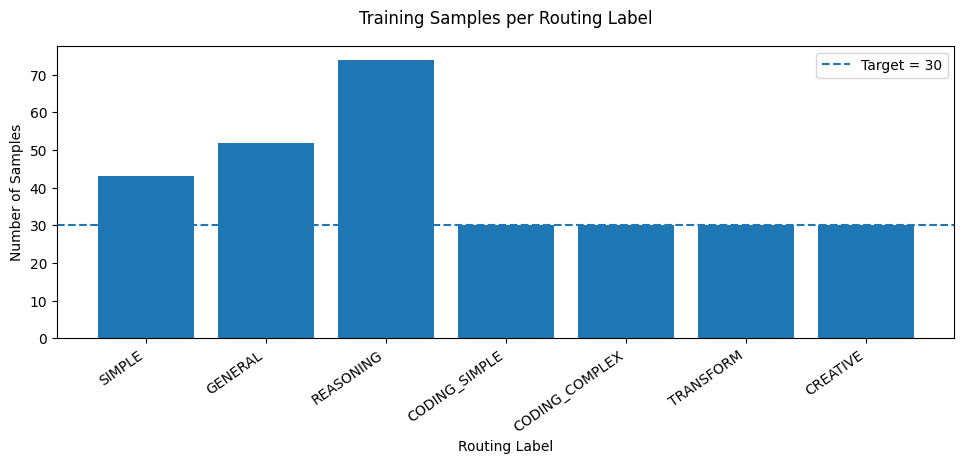


## Real Prompt Routing Test


,ID,Prompt,Route,Confidence,Second Choice,Second Score
0,1,berapa 15 persen dari 500,SIMPLE,0.283,TRANSFORM,0.213
1,2,jelaskan fungsi docker compose,CODING_SIMPLE,0.294,GENERAL,0.196
2,3,bandingkan REST dan GraphQL untuk backend apli...,CODING_COMPLEX,0.284,REASONING,0.259
3,4,buat regex untuk validasi email,CODING_SIMPLE,0.544,TRANSFORM,0.135
4,5,buat function python untuk parsing json,CODING_SIMPLE,0.389,CODING_COMPLEX,0.150
5,6,debug kenapa service systemd restart terus dan...,CODING_COMPLEX,0.377,REASONING,0.268
6,7,ringkas tulisan ini menjadi lima poin,SIMPLE,0.395,TRANSFORM,0.266
7,8,terjemahkan kalimat ini ke bahasa Jepang,TRANSFORM,0.484,SIMPLE,0.175
8,9,buat cerita pendek tentang robot kecil,CREATIVE,0.461,TRANSFORM,0.173
9,10,kenapa request API direct cepat tapi lewat rou...,REASONING,0.353,CODING_COMPLEX,0.301


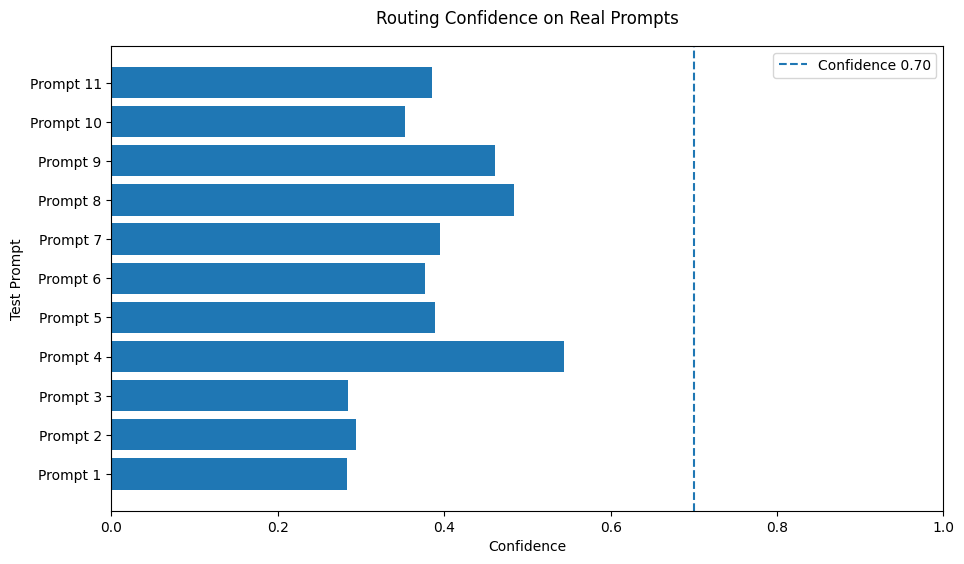


## Confusion Matrix


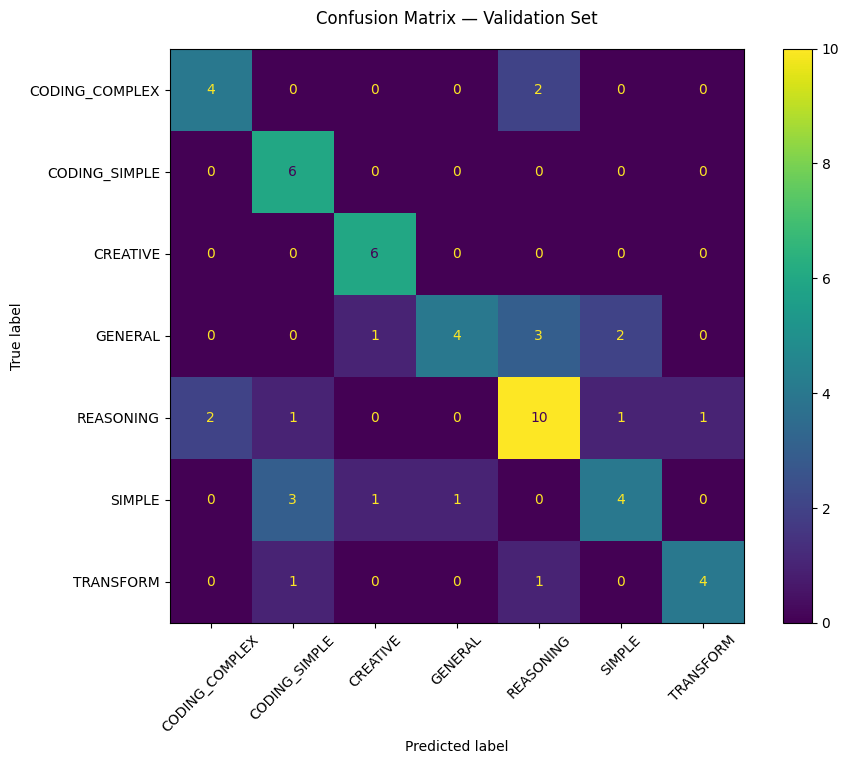


## Normalized Confusion Matrix


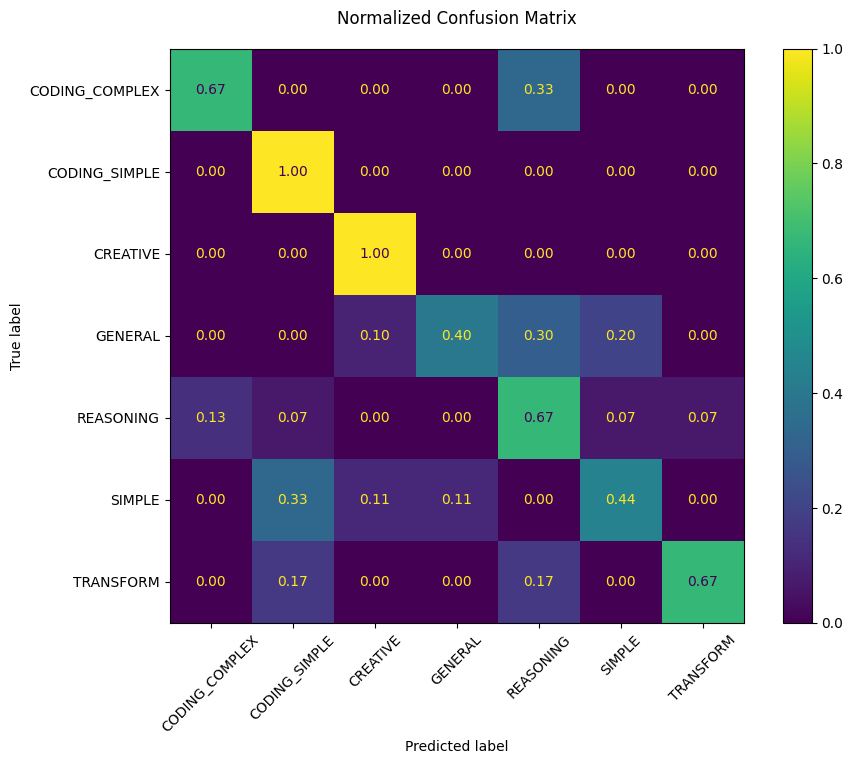


## Predicted Routes on Real Prompts


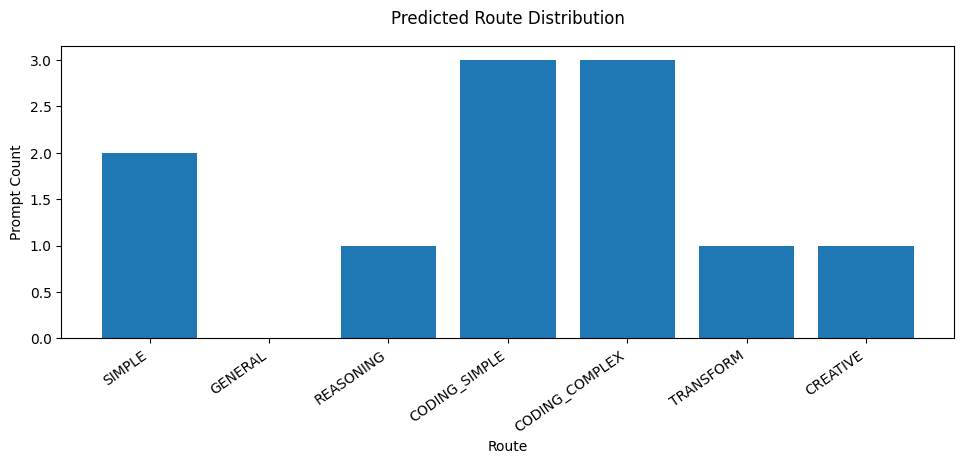


## Auto-Tuning History


,timestamp,samples,target_per_label,accuracy,macro_f1,count_SIMPLE,count_GENERAL,count_REASONING,count_CODING_SIMPLE,count_CODING_COMPLEX,count_TRANSFORM,count_CREATIVE
0,2026-08-23 10:14:42.151172,187,30,0.500000,0.393557,38,36,41,3,9,30,30
1,2026-08-23 10:32:06.542951,210,30,0.476190,0.424425,38,43,52,4,13,30,30
2,2026-08-23 12:37:25.665214,228,30,0.521739,0.450216,38,49,60,5,16,30,30
3,2026-08-23 12:54:45.208393,267,30,0.444444,0.437550,43,51,67,23,23,30,30
4,2026-08-23 12:58:13.750565,281,30,0.596491,0.623875,43,52,71,30,25,30,30
5,2026-08-24 00:25:19.200917,286,30,0.655172,0.655757,43,52,73,30,28,30,30
6,2026-08-24 00:26:25.215594,288,30,0.672414,0.679933,43,52,74,30,29,30,30
7,2026-08-24 00:27:45.358912,289,30,0.655172,0.662208,43,52,74,30,30,30,30


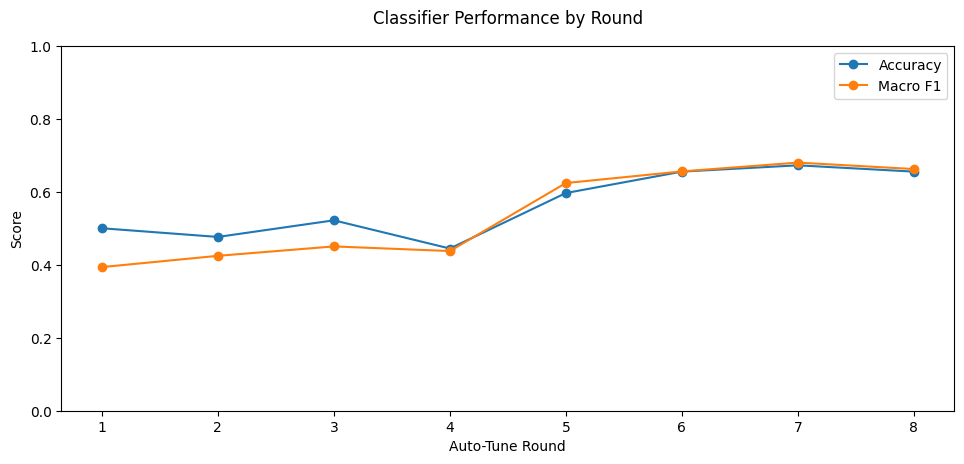



REPORT FINISHED


In [67]:
# =========================================================
# CHECK + VISUALIZE LAST ROUND — CLEAN VERSION
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

from IPython.display import display, Markdown


# =========================================================
# 1. HEADER + METRICS
# =========================================================

display(
    Markdown(
        """
# Router Classifier — Last Round Report
"""
    )
)

if metrics_current is not None:

    metrics_df = pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Macro F1",
                "Test Samples",
                "Total Dataset"
            ],
            "Value": [
                round(metrics_current["accuracy"], 3),
                round(metrics_current["macro_f1"], 3),
                metrics_current["test_samples"],
                len(df_balanced)
            ]
        }
    )

    display(metrics_df)

else:
    print("Metrics belum tersedia.")


# =========================================================
# 2. DATASET DISTRIBUTION
# =========================================================

display(
    Markdown(
        """
## Dataset Distribution
"""
    )
)

label_counts = (
    df_balanced["label"]
    .value_counts()
    .reindex(LABELS, fill_value=0)
)

distribution_df = pd.DataFrame(
    {
        "Label": label_counts.index,
        "Samples": label_counts.values,
        "Target": TARGET_PER_LABEL,
    }
)

distribution_df["Remaining"] = (
    distribution_df["Target"]
    - distribution_df["Samples"]
).clip(lower=0)

display(distribution_df)


# =========================================================
# 3. PLOT DATASET DISTRIBUTION
# =========================================================

fig = plt.figure(figsize=(10, 5))

plt.bar(
    label_counts.index,
    label_counts.values
)

plt.axhline(
    TARGET_PER_LABEL,
    linestyle="--",
    linewidth=1.5,
    label=f"Target = {TARGET_PER_LABEL}"
)

plt.title(
    "Training Samples per Routing Label",
    pad=16
)

plt.xlabel("Routing Label")
plt.ylabel("Number of Samples")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend()

plt.tight_layout(
    pad=2.0
)

plt.show()

print("\n")


# =========================================================
# 4. REAL PROMPT TEST
# =========================================================

display(
    Markdown(
        """
## Real Prompt Routing Test
"""
    )
)

if classifier_current is None:
    raise RuntimeError(
        "classifier_current belum tersedia."
    )

test_embeddings = embedding_model.encode(
    REAL_TEST_PROMPTS,
    normalize_embeddings=True
)

predictions = classifier_current.predict(
    test_embeddings
)

probabilities = classifier_current.predict_proba(
    test_embeddings
)


real_results = []

for i, (prompt, label, probs) in enumerate(
    zip(
        REAL_TEST_PROMPTS,
        predictions,
        probabilities
    ),
    start=1
):

    confidence = float(
        probs.max()
    )

    order = np.argsort(
        probs
    )[::-1]

    second_idx = order[1]

    real_results.append(
        {
            "ID": i,
            "Prompt": prompt,
            "Route": label,
            "Confidence": round(
                confidence,
                3
            ),
            "Second Choice":
                classifier_current.classes_[
                    second_idx
                ],
            "Second Score": round(
                float(
                    probs[
                        second_idx
                    ]
                ),
                3
            )
        }
    )


df_real_test = pd.DataFrame(
    real_results
)

display(df_real_test)


# =========================================================
# 5. CONFIDENCE PLOT
# =========================================================

fig = plt.figure(figsize=(10, 6))

positions = np.arange(
    len(df_real_test)
)

plt.barh(
    positions,
    df_real_test[
        "Confidence"
    ]
)

plt.yticks(
    positions,
    [
        f"Prompt {i}"
        for i in df_real_test["ID"]
    ]
)

plt.axvline(
    0.70,
    linestyle="--",
    linewidth=1.5,
    label="Confidence 0.70"
)

plt.xlim(
    0,
    1
)

plt.title(
    "Routing Confidence on Real Prompts",
    pad=16
)

plt.xlabel("Confidence")
plt.ylabel("Test Prompt")

plt.legend()

plt.tight_layout(
    pad=2.0
)

plt.show()

print("\n")


# =========================================================
# 6. CONFUSION MATRIX
# =========================================================

display(
    Markdown(
        """
## Confusion Matrix
"""
    )
)

# Supaya confusion matrix valid,
# kita buat ulang test split yang sama dengan train_router()

X_all = embedding_model.encode(
    df_balanced["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=False,
    normalize_embeddings=True
)

y_all = df_balanced[
    "label"
].values


from sklearn.model_selection import train_test_split

(
    X_train_check,
    X_test_check,
    y_train_check,
    y_test_check
) = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

y_pred_check = classifier_current.predict(
    X_test_check
)

cm_labels = list(
    classifier_current.classes_
)

cm = confusion_matrix(
    y_test_check,
    y_pred_check,
    labels=cm_labels
)

fig = plt.figure(
    figsize=(10, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cm_labels
)

disp.plot(
    ax=plt.gca(),
    values_format="d",
    xticks_rotation=45
)

plt.title(
    "Confusion Matrix — Validation Set",
    pad=18
)

plt.tight_layout(
    pad=2.0
)

plt.show()

print("\n")


# =========================================================
# 7. NORMALIZED CONFUSION MATRIX
# =========================================================

display(
    Markdown(
        """
## Normalized Confusion Matrix
"""
    )
)

cm_normalized = confusion_matrix(
    y_test_check,
    y_pred_check,
    labels=cm_labels,
    normalize="true"
)

fig = plt.figure(
    figsize=(10, 8)
)

disp_normalized = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=cm_labels
)

disp_normalized.plot(
    ax=plt.gca(),
    values_format=".2f",
    xticks_rotation=45
)

plt.title(
    "Normalized Confusion Matrix",
    pad=18
)

plt.tight_layout(
    pad=2.0
)

plt.show()

print("\n")


# =========================================================
# 8. ROUTE DISTRIBUTION — REAL TEST
# =========================================================

display(
    Markdown(
        """
## Predicted Routes on Real Prompts
"""
    )
)

route_counts = (
    df_real_test[
        "Route"
    ]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

fig = plt.figure(
    figsize=(10, 5)
)

plt.bar(
    route_counts.index,
    route_counts.values
)

plt.title(
    "Predicted Route Distribution",
    pad=16
)

plt.xlabel("Route")
plt.ylabel("Prompt Count")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout(
    pad=2.0
)

plt.show()

print("\n")


# =========================================================
# 9. TUNING HISTORY
# =========================================================

display(
    Markdown(
        """
## Auto-Tuning History
"""
    )
)

if os.path.exists(
    ROUND_LOG_PATH
):

    history_df = pd.read_csv(
        ROUND_LOG_PATH
    )

    display(
        history_df.tail(10)
    )

    if len(history_df) >= 2:

        fig = plt.figure(
            figsize=(10, 5)
        )

        rounds = np.arange(
            1,
            len(history_df) + 1
        )

        plt.plot(
            rounds,
            history_df[
                "accuracy"
            ],
            marker="o",
            label="Accuracy"
        )

        plt.plot(
            rounds,
            history_df[
                "macro_f1"
            ],
            marker="o",
            label="Macro F1"
        )

        plt.ylim(
            0,
            1
        )

        plt.xlabel(
            "Auto-Tune Round"
        )

        plt.ylabel(
            "Score"
        )

        plt.title(
            "Classifier Performance by Round",
            pad=16
        )

        plt.legend()

        plt.tight_layout(
            pad=2.0
        )

        plt.show()

    else:
        print(
            "History baru punya 1 round. "
            "Grafik trend muncul setelah round berikutnya."
        )

else:

    print(
        "Round history belum tersedia."
    )


print("\n")
print("=" * 60)
print("REPORT FINISHED")
print("=" * 60)

In [63]:
import os

SAVE_DIR = "/content/drive/MyDrive/router_classifier"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

# dataset terbaru dari RAM
df_balanced.to_csv(
    f"{SAVE_DIR}/router_dataset_current.csv",
    index=False
)

print(
    "Dataset saved:",
    len(df_balanced)
)

Dataset saved: 288


In [64]:
import shutil
import os

files_to_backup = [
    "router_teacher_checkpoint.csv",
    "router_teacher_extra_all.csv",
    "router_tuning_rounds.csv",
    "router_classifier_current.joblib",
]

for filename in files_to_backup:

    src = f"/content/{filename}"
    dst = f"{SAVE_DIR}/{filename}"

    if os.path.exists(src):

        shutil.copy2(
            src,
            dst
        )

        print(
            "Copied:",
            filename
        )

In [65]:
print("BASE:", BASE_PATH)
print("EXTRA:", EXTRA_ALL_PATH)
print("DATASET:", CURRENT_DATASET_PATH)
print("LOG:", ROUND_LOG_PATH)

BASE: /content/drive/MyDrive/router_classifier/router_teacher_checkpoint.csv
EXTRA: /content/drive/MyDrive/router_classifier/router_teacher_extra_all.csv
DATASET: /content/drive/MyDrive/router_classifier/router_dataset_current.csv
LOG: /content/drive/MyDrive/router_classifier/router_tuning_rounds.csv
